## Практическое задание 1

### 1.1. Цель работы
Данная практическая работа ставит перед собой задачу познакомить с процессом
вычисления стандартных описательных статистик для выборок данных различных
типов и научить использовать методы агрегации статистических данных с целью
получения новых знаний об их эмпирическом распределении.
При выполнении данной практической работы вам предстоит собрать данные и
рассчитать на их основе простейшие статистические показатели.

### 1.2. Постановка задачи
Для выполнения данной практической работы студентам учебной группы
необходимо разделиться на две максимально близкие по численности подгруппы.
Каждому студенту необходимо будет решить две подзадачи:
1. Собрать данные.
2. Обработать собранные данные (рассчитать статистики и построить
диаграммы).

### 2.3. Сбор данных
Студенты обеих подгрупп должны собрать данные о росте учащихся всей
учебной группы в сантиметрах. Собранные данные рассматривать в вещественных.
Студенты первой подгруппы должны собрать номера месяцев рождения со всей
подгруппы. Собранные данные рассматривать, как целочисленные.
Студенты второй подгруппы должны собрать данные о загаданном случайном
целом числе на интервале [0; 8]. Необходимо провести сбор данных так, чтобы
опрашиваемые студенты не знали, какие числа загадали их одногруппники.
Собранные данные рассматривать как целочисленные.

In [12]:

float_data = [159, 190, 176, 185, 181, 198, 174, 177, 192, 170, 169, 180, 168, 175, 161, 168, 180, 173, 183, 173, 167, 172, 175, 148, 168, 164, 187, 140, 181]
int_data = [4, 5, 5, 1, 5, 5, 6, 3, 7, 3, 4, 7, 4, 2, 6]

In [13]:
print(float_data)
print(int_data)

[159, 190, 176, 185, 181, 198, 174, 177, 192, 170, 169, 180, 168, 175, 161, 168, 180, 173, 183, 173, 167, 172, 175, 148, 168, 164, 187, 140, 181]
[4, 5, 5, 1, 5, 5, 6, 3, 7, 3, 4, 7, 4, 2, 6]


### 1.4. Обработка данных

#### 1. Построить вариационный ряд с абсолютным и относительными частотами по выборке дискретных данных.

In [14]:
import numpy as np
from collections import Counter

len_int_data = len(int_data)

# Подсчет абсолютных частот
absolute_freq = Counter(int_data)

# Получаем уникальные значения, отсортированные по возрастанию
unique_values = sorted(absolute_freq.keys())

# Создаем вариационный ряд
variation_series = []
for value in unique_values:
    abs_freq = absolute_freq[value]
    rel_freq = abs_freq / len_int_data
    variation_series.append({
        'value': value,
        'abs_f': abs_freq,
        'rel_f': rel_freq
    })

# Выводим результаты
print("Вариационный ряд:")
print("-" * 40)
print(f"{'Значение':<10} | {'Абс. частота':<12} | {'Отн. частота':<12}")
print("-" * 40)
for row in variation_series:
    print(f"{row['value']:<10} | {row['abs_f']:<12} | {row['rel_f']:<12.3f}")

# Проверка сумм
total_abs = sum(absolute_freq.values())
total_rel = sum(row['rel_f'] for row in variation_series)

print("-" * 40)
print(f"{'Сумма':<10} | {total_abs:<12} | {total_rel:<12.3f}")

# Дополнительная информация
print(f"\nОбъем выборки: {len_int_data}")
print("Уникальные значения:", unique_values)

Вариационный ряд:
----------------------------------------
Значение   | Абс. частота | Отн. частота
----------------------------------------
1          | 1            | 0.067       
2          | 1            | 0.067       
3          | 2            | 0.133       
4          | 3            | 0.200       
5          | 4            | 0.267       
6          | 2            | 0.133       
7          | 2            | 0.133       
----------------------------------------
Сумма      | 15           | 1.000       

Объем выборки: 15
Уникальные значения: [1, 2, 3, 4, 5, 6, 7]


#### 2. Построить полигон относительных частот вариационного ряда

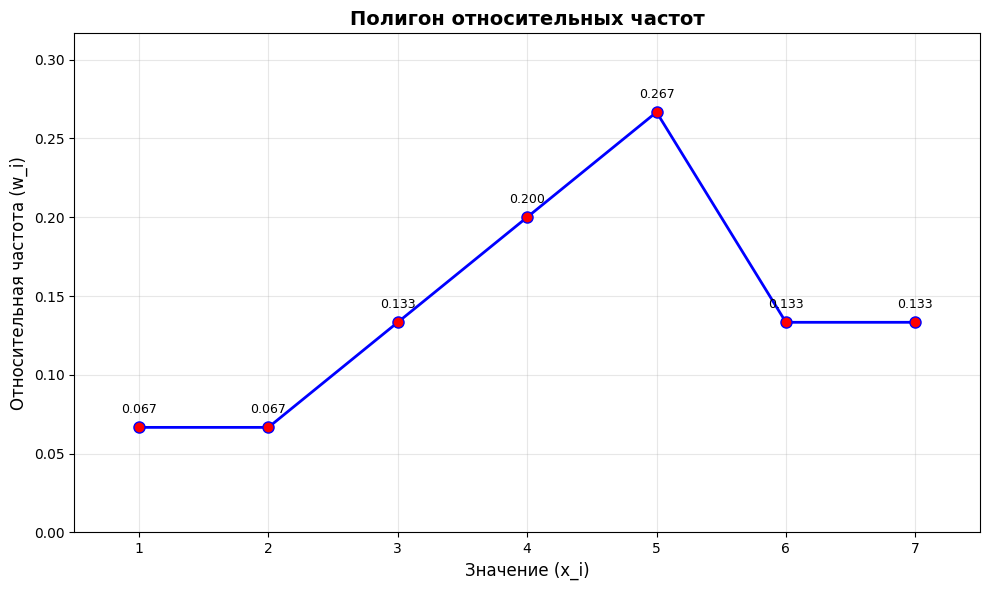

In [15]:
import matplotlib.pyplot as plt

# Рассчитываем относительные частоты
relative_freq = [absolute_freq[value] / len_int_data for value in unique_values]

# Создаем график
plt.figure(figsize=(10, 6))

# Построение полигона частот
plt.plot(unique_values, relative_freq, 'bo-', linewidth=2, markersize=8, markerfacecolor='red')

# Настройка графика
plt.title('Полигон относительных частот', fontsize=14, fontweight='bold')
plt.xlabel('Значение (x_i)', fontsize=12)
plt.ylabel('Относительная частота (w_i)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(unique_values)

# Добавляем подписи значений на точки
for x, y in zip(unique_values, relative_freq):
    plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=9)

# Устанавливаем пределы по осям
plt.xlim(min(unique_values) - 0.5, max(unique_values) + 0.5)
plt.ylim(0, max(relative_freq) + 0.05)

plt.tight_layout()
plt.show()

#### 3. Выписать выражение для эмпирической функции распределения и построить её график.

In [16]:
# Сортируем данные
sorted_data = sorted(int_data)
unique_values = sorted(set(int_data))

# Вычисляем накопленные частоты
absolute_freq = Counter(int_data)
cumulative_freq = {}
cumulative = 0

print("Расчет эмпирической функции распределения:")
print("x\tНакапливаемая частота\tF*(x)")
print("-" * 35)

for x in unique_values:
    cumulative += absolute_freq[x]
    cumulative_freq[x] = cumulative / len_int_data
    print(f"{x}\t{cumulative}/{len_int_data}\t\t{cumulative/len_int_data:.3f}")

Расчет эмпирической функции распределения:
x	Накапливаемая частота	F*(x)
-----------------------------------
1	1/15		0.067
2	2/15		0.133
3	4/15		0.267
4	7/15		0.467
5	11/15		0.733
6	13/15		0.867
7	15/15		1.000


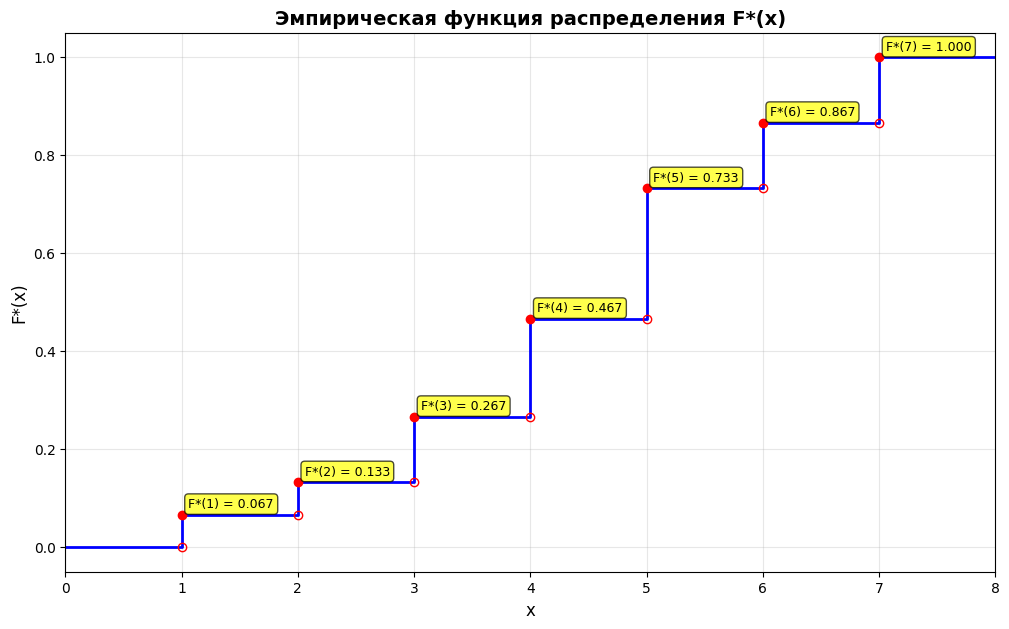


АНАЛИТИЧЕСКОЕ ВЫРАЖЕНИЕ ЭМПИРИЧЕСКОЙ ФУНКЦИИ:
F*(x) = {
    0,          при x ≤ 1
    1/15 ≈ 0.067, при 1 < x ≤ 2
    2/15 ≈ 0.133, при 2 < x ≤ 3
    4/15 ≈ 0.267, при 3 < x ≤ 4
    7/15 ≈ 0.467, при 4 < x ≤ 5
    11/15 ≈ 0.733, при 5 < x ≤ 6
    13/15 ≈ 0.867, при 6 < x ≤ 7
    1,          при x > 7
}


In [17]:
# Создаем точки для графика
x_points = []
y_points = []

# Добавляем начальную точку
x_points.append(sorted_data[0] - 1)
y_points.append(0)

# Добавляем точки скачков
for i, val in enumerate(unique_values):
    x_points.append(val)
    y_points.append(cumulative_freq[val])
    if i < len(unique_values) - 1:
        x_points.append(unique_values[i+1])
        y_points.append(cumulative_freq[val])

# Добавляем конечную точку
x_points.append(unique_values[-1] + 1)
y_points.append(1)

# Строим график
plt.figure(figsize=(12, 7))
plt.step(x_points, y_points, where='post', linewidth=2, color='blue')

# Настройка графика
plt.title('Эмпирическая функция распределения F*(x)', fontsize=14, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('F*(x)', fontsize=12)
plt.grid(True, alpha=0.3)

# Добавляем точки разрыва
for x in unique_values:
    plt.plot(x, cumulative_freq[x], 'ro', markersize=6)
    plt.plot(x, cumulative_freq[x] - absolute_freq[x]/len_int_data, 'ro', fillstyle='none', markersize=6)

# Добавляем подписи
for x in unique_values:
    y_val = cumulative_freq[x]
    plt.annotate(f'F*({x}) = {y_val:.3f}', 
                (x, y_val), 
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.xlim(min(int_data)-1, max(int_data)+1)
plt.ylim(-0.05, 1.05)
plt.xticks(range(min(int_data)-1, max(int_data)+2))

plt.show()

# Вывод аналитического выражения
print("\n" + "="*50)
print("АНАЛИТИЧЕСКОЕ ВЫРАЖЕНИЕ ЭМПИРИЧЕСКОЙ ФУНКЦИИ:")
print("="*50)
print("F*(x) = {")
print("    0,          при x ≤ 1")
print("    1/15 ≈ 0.067, при 1 < x ≤ 2")
print("    2/15 ≈ 0.133, при 2 < x ≤ 3")
print("    4/15 ≈ 0.267, при 3 < x ≤ 4")
print("    7/15 ≈ 0.467, при 4 < x ≤ 5")
print("    11/15 ≈ 0.733, при 5 < x ≤ 6")
print("    13/15 ≈ 0.867, при 6 < x ≤ 7")
print("    1,          при x > 7")
print("}")

#### 4. Рассчитать выборочные описательные статистики:

In [18]:
int_data = [4, 5, 5, 1, 5, 5, 6, 3, 7, 3, 4, 7, 4, 2, 6]
import numpy as np
# 1. Выборочное среднее
int_mean = np.mean(int_data)
# 2. Выборочная дисперсия
int_var = np.var(int_data, ddof=1)
# 3. Выборочное стандартное отклонение
int_std = np.std(int_data, ddof=1)
# 4. Выборочная медиана
int_median = np.median(int_data)
# 5. Коэффициент вариации
int_coeff_var = int_std / int_mean * 100

print("1. Выборочное среднее:", round(int_mean, 4))
print("2. Выборочная дисперсия:", round(int_var, 4))
print("3. Выборочное стандартное отклонения:", round(int_std, 4))
print("4. Выборочная медиана:", int_median)
print("5. Коэффициент вариации:", round(int_coeff_var, 2), "%")

1. Выборочное среднее: 4.4667
2. Выборочная дисперсия: 2.981
3. Выборочное стандартное отклонения: 1.7265
4. Выборочная медиана: 5.0
5. Коэффициент вариации: 38.65 %


#### 1. Рассчитать число групп (интервалов) g для квантования исходных данных по правилу Стёрджесса.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from math import log10, ceil

len_float_data = len(float_data)
# Формула Стёрджесса: k = 1 + 3.322*lg(N)
g = ceil(1 + 3.322 * log10(len_float_data))
print("Число групп по правилу Стёрджесса:")
print(f"g = ceil(1 + 3.322 * log10({len_float_data})) = {g}")

Число групп по правилу Стёрджесса:
g = ceil(1 + 3.322 * log10(29)) = 6


#### Вычислить значения границ групп Zi,j=0,1,..,g для значений выборки по правилу фиксированной величины интервала.

In [20]:
data_min = min(float_data)
data_max = max(float_data)
h = (data_max - data_min) / g  # Ширина интервала
print("Границы групп:")
print(f"   min = {data_min}, max = {data_max}")
print(f"   Ширина интервала h = ({data_max} - {data_min}) / {g} = {h:.2f}")
print()

# Создаем границы интервалов
intervals = []
current = data_min
for i in range(g + 1):
    intervals.append(current)
    current += h

print("Границы интервалов:")
for i in range(len(intervals) - 1):
    print(f"   [{intervals[i]:.2f}, {intervals[i+1]:.2f})")

Границы групп:
   min = 140, max = 198
   Ширина интервала h = (198 - 140) / 6 = 9.67

Границы интервалов:
   [140.00, 149.67)
   [149.67, 159.33)
   [159.33, 169.00)
   [169.00, 178.67)
   [178.67, 188.33)
   [188.33, 198.00)


#### 3. Построить вариационный ряд для выборки интервальных данных.

In [21]:
# 3. Вариационный ряд для интервальных данных
interval_midpoints = []
absolute_freq = [0] * g
relative_freq = [0] * g

# Подсчет частот
for value in float_data:
    for i in range(g):
        if intervals[i] <= value < intervals[i+1]:
            absolute_freq[i] += 1
            break
    else:
        if value == intervals[-1]:
            absolute_freq[-1] += 1

# Относительные частоты и середины интервалов
for i in range(g):
    relative_freq[i] = absolute_freq[i] / len_float_data
    interval_midpoints.append((intervals[i] + intervals[i+1]) / 2)

print("3. Вариационный ряд для интервальных данных:")
print("   Интервал\t\tСередина\tАбс. частота\tОтн. частота")
print("   " + "-" * 55)
for i in range(g):
    print(f"   [{intervals[i]:.2f}, {intervals[i+1]:.2f})\t{interval_midpoints[i]:.2f}\t\t{absolute_freq[i]}\t\t{relative_freq[i]:.3f}")
print(f"   Сумма:\t\t\t\t{sum(absolute_freq)}\t\t{sum(relative_freq):.3f}")
print()

3. Вариационный ряд для интервальных данных:
   Интервал		Середина	Абс. частота	Отн. частота
   -------------------------------------------------------
   [140.00, 149.67)	144.83		2		0.069
   [149.67, 159.33)	154.50		1		0.034
   [159.33, 169.00)	164.17		6		0.207
   [169.00, 178.67)	173.83		10		0.345
   [178.67, 188.33)	183.50		7		0.241
   [188.33, 198.00)	193.17		2		0.069
   Сумма:				28		0.966



#### 4. Построить гистограмму распределения относительных частот для рассчитанных интервалов выборки

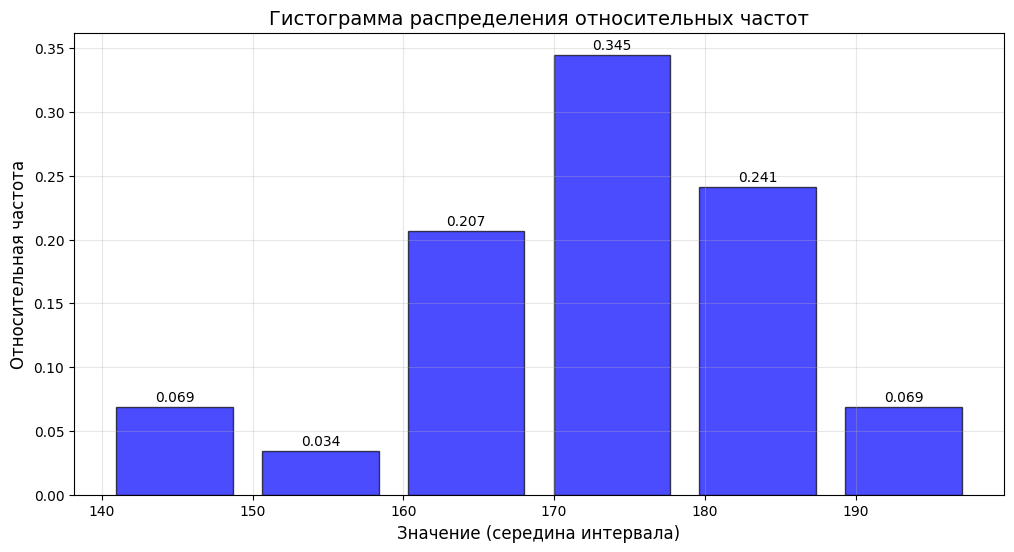

In [22]:
plt.figure(figsize=(12, 6))
plt.bar(interval_midpoints, relative_freq, width=h*0.8, 
        edgecolor='black', alpha=0.7, color='blue')
plt.title('Гистограмма распределения относительных частот', fontsize=14)
plt.xlabel('Значение (середина интервала)', fontsize=12)
plt.ylabel('Относительная частота', fontsize=12)
plt.grid(True, alpha=0.3)

for i, (x, y) in enumerate(zip(interval_midpoints, relative_freq)):
    plt.text(x, y + 0.002, f'{y:.3f}', ha='center', va='bottom')

plt.show()

#### 5. Выписать выражение для эмпирической функции распределения и построить её график.

Эмпирическая функция распределения F*(x):
   Интервал		F*(x)
   ------------------------------
   x ≤ 140.00	0.000
   x ≤ 149.67	0.069
   x ≤ 159.33	0.103
   x ≤ 169.00	0.310
   x ≤ 178.67	0.655
   x ≤ 188.33	0.897
   x > 198.00	1.000


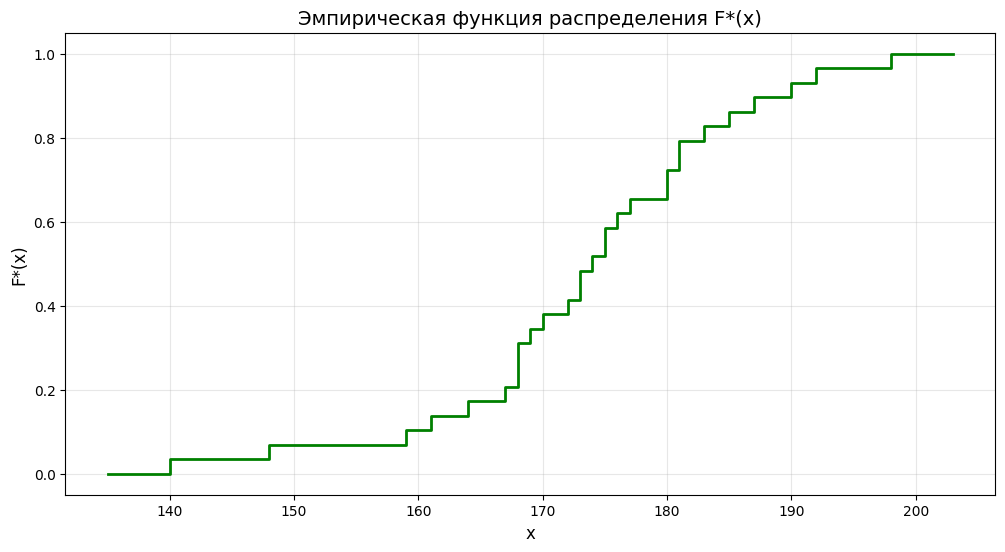

In [23]:
sorted_data = sorted(float_data)
empirical_cdf = []

print("Эмпирическая функция распределения F*(x):")
print("   Интервал\t\tF*(x)")
print("   " + "-" * 30)

cumulative = 0
for i in range(g + 1):
    if i == 0:
        print(f"   x ≤ {intervals[0]:.2f}\t0.000")
    elif i == g:
        print(f"   x > {intervals[g]:.2f}\t1.000")
    else:
        count_in_interval = sum(1 for x in sorted_data if x <= intervals[i])
        cumulative = count_in_interval / len_float_data
        print(f"   x ≤ {intervals[i]:.2f}\t{cumulative:.3f}")

# График эмпирической функции распределения
plt.figure(figsize=(12, 6))
x_points = [data_min - 5] + sorted_data + [data_max + 5]
y_points = [0] + [i/len_float_data for i in range(1, len_float_data+1)] + [1]

plt.step(x_points, y_points, where='post', linewidth=2, color='green')
plt.title('Эмпирическая функция распределения F*(x)', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('F*(x)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.show()

#### 6. Рассчитать выборочные описательные статистики:

In [24]:
float_mean = np.mean(float_data)
float_var = np.var(float_data, ddof=1)
float_std = np.std(float_data, ddof=1)
float_median = np.median(float_data)
float_coeff_var = (float_std / float_mean) * 100

print(f"Выборочное среднее: {float_mean:.4f}")
print(f"Выборочная дисперсия: {float_var:.4f}")
print(f"Выборочное стандартное отклонение: {float_std:.4f}")
print(f"Выборочная медиана: {float_median:.4f}")
print(f"Коэффициент вариации: {float_coeff_var:.2f} %")

Выборочное среднее: 173.5862
Выборочная дисперсия: 151.3227
Выборочное стандартное отклонение: 12.3013
Выборочная медиана: 174.0000
Коэффициент вариации: 7.09 %
